**Python implementation code of Lotka-Voltera model, base paper WyNDA**

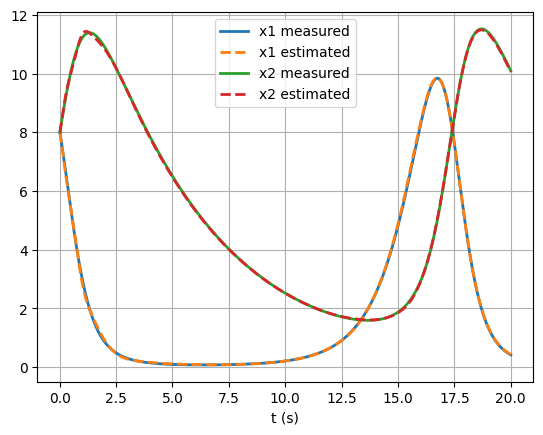

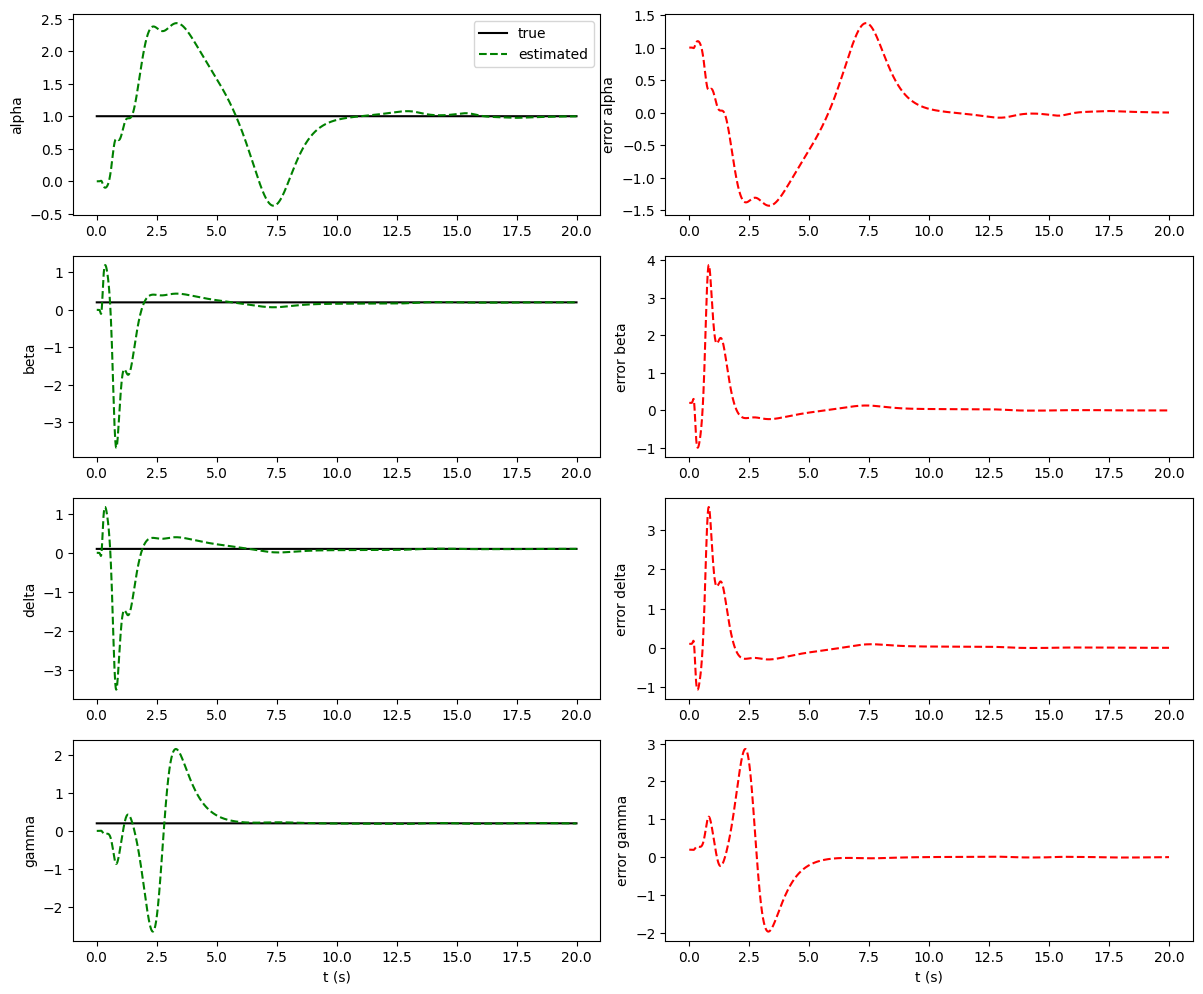

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Defining time horizon
tf = 20
dt = 0.01
t = np.arange(dt, tf + dt, dt)

# system dimension
n = 2
r = 14

# noise into system
R = 0

# state initialization
x = np.array([8., 8.])
xbar = x.copy()
y = x.copy()
thetabar = np.zeros(r)

# true parameters
alpha = 1
beta = 0.2
delta = 0.1
gamma = 0.2

# storage analysis
xArray = []
xbarArray = []
yArray = []
thetabarArray = []

# estimator initialization
lambdav = 0.995
lambdat = 0.999

Rx = np.eye(n)
Rt = np.eye(n)

Px = 0.1 * np.eye(n)
Pt = 0.1 * np.eye(r)

Gamma = np.zeros((n, r))

# simulation
for i in range(int(tf/dt)):

    xArray.append(x.copy())
    xbarArray.append(xbar.copy())
    yArray.append(y.copy())
    thetabarArray.append(thetabar.copy())

    # Lotka-Volterra dynamics
    dx = np.array([
        alpha*x[0] - beta*x[0]*x[1],
        delta*x[0]*x[1] - gamma*x[1]
    ])

    x = x + dt * dx
    y = x + dt*(R**2)*np.random.randn(n)

    # library matrix phi
    Phi = np.zeros((2,14))

    Phi[0,0:7] = [
        y[0], y[1],
        y[0]**2, y[1]**2,
        y[0]*y[1],
        y[0]**3, y[1]**3
    ]

    Phi[1,7:14] = Phi[0,0:7]

    # adaptive observer
    Kx = Px @ np.linalg.inv(Px + Rx)
    Kt = Pt @ Gamma.T @ np.linalg.inv(Gamma @ Pt @ Gamma.T + Rt)

    Gamma = (np.eye(n) - Kx) @ Gamma

    xbar = xbar + (Kx + Gamma @ Kt) @ (y - xbar)
    thetabar = thetabar - Kt @ (y - xbar)

    xbar = xbar + Phi @ thetabar

    Px = (1/lambdav) * (np.eye(n) - Kx) @ Px
    Pt = (1/lambdat) * (np.eye(r) - Kt @ Gamma) @ Pt

    Gamma = Gamma - Phi


# convert arrays
xArray = np.array(xArray).T
xbarArray = np.array(xbarArray).T
yArray = np.array(yArray).T
thetabarArray = np.array(thetabarArray).T


# figure 1: states vs time
plt.figure()

plt.plot(t, yArray[0], linewidth=2)
plt.plot(t, xbarArray[0], '--', linewidth=2)

plt.plot(t, yArray[1], linewidth=2)
plt.plot(t, xbarArray[1], '--', linewidth=2)

plt.grid(True)
plt.xlabel("t (s)")
plt.legend(["x1 measured", "x1 estimated", "x2 measured", "x2 estimated"])

plt.show()


# figure 2: parameter estimation
fig, axs = plt.subplots(4,2, figsize=(12,10))

# alpha
axs[0,0].plot(t, alpha*np.ones_like(t),'k')
axs[0,0].plot(t, thetabarArray[0]/dt,'g--')
axs[0,0].set_ylabel("alpha")
axs[0,0].legend(["true","estimated"])

axs[0,1].plot(t, alpha - thetabarArray[0]/dt,'r--')
axs[0,1].set_ylabel("error alpha")

# beta
axs[1,0].plot(t, beta*np.ones_like(t),'k')
axs[1,0].plot(t, -thetabarArray[4]/dt,'g--')
axs[1,0].set_ylabel("beta")

axs[1,1].plot(t, beta + thetabarArray[4]/dt,'r--')
axs[1,1].set_ylabel("error beta")

# delta
axs[2,0].plot(t, delta*np.ones_like(t),'k')
axs[2,0].plot(t, thetabarArray[11]/dt,'g--')
axs[2,0].set_ylabel("delta")

axs[2,1].plot(t, delta - thetabarArray[11]/dt,'r--')
axs[2,1].set_ylabel("error delta")

# gamma
axs[3,0].plot(t, gamma*np.ones_like(t),'k')
axs[3,0].plot(t, -thetabarArray[8]/dt,'g--')
axs[3,0].set_ylabel("gamma")
axs[3,0].set_xlabel("t (s)")

axs[3,1].plot(t, gamma + thetabarArray[8]/dt,'r--')
axs[3,1].set_ylabel("error gamma")
axs[3,1].set_xlabel("t (s)")

plt.tight_layout()
plt.show()

